C5.0 is decision id used for classification
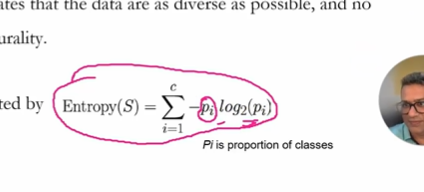

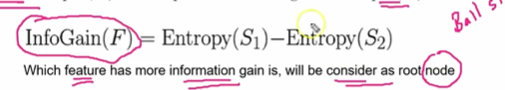

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [32]:
df=pd.read_csv("car_evaluation.csv")


In [33]:
df.head()

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [34]:
df.shape

(1727, 7)

In [35]:
col_name=["buying","maint","doors","persons","lug_boot","safety","class"]
df.columns=col_name
col_name

['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

In [36]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [37]:
df.dtypes

buying      object
maint       object
doors       object
persons     object
lug_boot    object
safety      object
class       object
dtype: object

In [38]:
df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1727 non-null   object
 1   maint     1727 non-null   object
 2   doors     1727 non-null   object
 3   persons   1727 non-null   object
 4   lug_boot  1727 non-null   object
 5   safety    1727 non-null   object
 6   class     1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [40]:
col_name=["buying","maint","doors","persons","lug_boot","safety","class"]
for col in col_name:
    print(df[col].value_counts())

buying
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
maint
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
doors
3        432
4        432
5more    432
2        431
Name: count, dtype: int64
persons
4       576
more    576
2       575
Name: count, dtype: int64
lug_boot
med      576
big      576
small    575
Name: count, dtype: int64
safety
med     576
high    576
low     575
Name: count, dtype: int64
class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [41]:
df["class"].value_counts()

class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64

In [42]:
x=df.drop(["class"],axis=1)
y=df["class"]


In [43]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42)

In [44]:
x_test

,buying,maint,doors,persons,lug_boot,safety
599,high,high,4,2,big,low
932,med,vhigh,4,4,big,low
628,high,high,5more,2,big,high
1497,low,high,5more,4,med,med
1262,med,low,4,more,med,low
...,...,...,...,...,...,...
1601,low,med,5more,4,small,low
1033,med,high,4,2,big,high
341,vhigh,low,2,more,small,low
147,vhigh,high,3,4,med,med


In [45]:
x_train.shape,x_test.shape

((1157, 6), (570, 6))

In [46]:
y_train.shape,y_test.shape

((1157,), (570,))

In [47]:
import category_encoders as ce

In [48]:
encoder=ce.OrdinalEncoder(cols=["buying","maint","doors","persons","lug_boot","safety"])

In [49]:
encoder

OrdinalEncoder(cols=['buying', 'maint', 'doors', 'persons', 'lug_boot',
                     'safety'])

In [50]:
x_train=encoder.fit_transform(x_train)

In [51]:
x_train.head()

,buying,maint,doors,persons,lug_boot,safety
83,1,1,1,1,1,1
48,1,1,2,2,1,2
468,2,1,2,3,2,2
155,1,2,2,2,1,1
1043,3,2,3,2,2,1


In [52]:
x_test=encoder.transform(x_test)

In [53]:
x_test.head()

,buying,maint,doors,persons,lug_boot,safety
599,2,2,3,1,3,1
932,3,1,3,3,3,1
628,2,2,1,1,3,3
1497,4,2,1,3,1,2
1262,3,4,3,2,1,1


In [54]:
from sklearn.tree import DecisionTreeClassifier
clf_gini=DecisionTreeClassifier(criterion='gini' ,max_depth=3 ,random_state=0)

In [55]:
clf_gini.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [56]:
y_pred_gini=clf_gini.predict(x_test)
y_pred_gini_train=clf_gini.predict(x_train)

In [57]:
y_pred_gini[:10]

array(['unacc', 'unacc', 'unacc', 'acc', 'unacc', 'acc', 'unacc', 'unacc',
       'acc', 'unacc'], dtype=object)

In [58]:
from sklearn.metrics import accuracy_score
print("Model accuracy {0:0.4f}".format(accuracy_score(y_test,y_pred_gini)))
print("Model accuracy {0:0.4f}".format(accuracy_score(y_train,y_pred_gini_train)))

Model accuracy 0.8053
Model accuracy 0.7848


[Text(0.3333333333333333, 0.875, 'x[5] <= 1.5\ngini = 0.457\nsamples = 1157\nvalue = [257, 51, 810, 39]'),
 Text(0.16666666666666666, 0.625, 'gini = 0.0\nsamples = 391\nvalue = [0, 0, 391, 0]'),
 Text(0.25, 0.75, 'True  '),
 Text(0.5, 0.625, 'x[3] <= 1.5\ngini = 0.581\nsamples = 766\nvalue = [257, 51, 419, 39]'),
 Text(0.41666666666666663, 0.75, '  False'),
 Text(0.3333333333333333, 0.375, 'gini = 0.0\nsamples = 242\nvalue = [0, 0, 242, 0]'),
 Text(0.6666666666666666, 0.375, 'x[0] <= 2.5\ngini = 0.63\nsamples = 524\nvalue = [257, 51, 177, 39]'),
 Text(0.5, 0.125, 'gini = 0.498\nsamples = 266\nvalue = [124, 0, 142, 0]'),
 Text(0.8333333333333334, 0.125, 'gini = 0.654\nsamples = 258\nvalue = [133, 51, 35, 39]')]

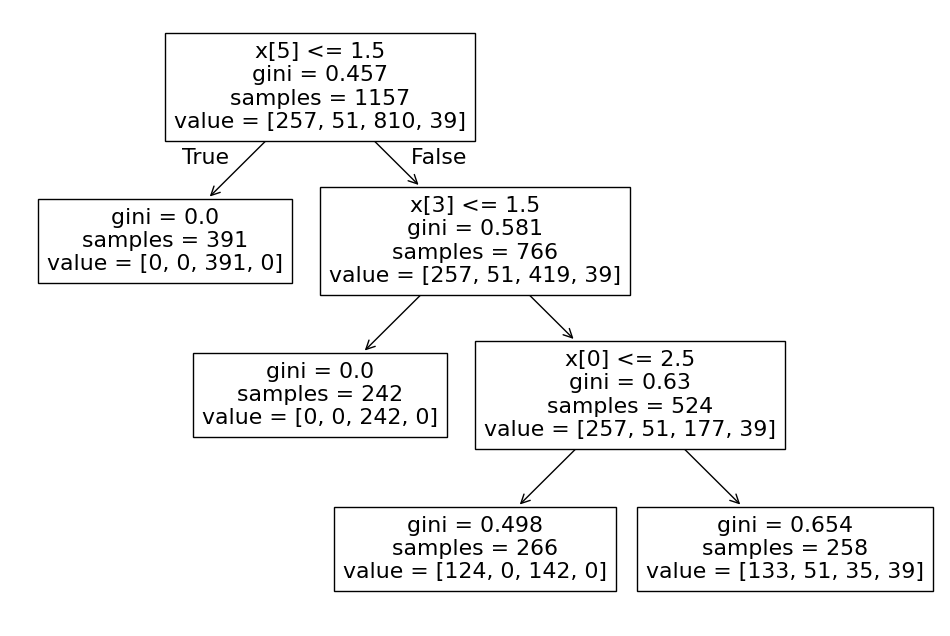

In [59]:
plt.figure(figsize=(12,8))
from sklearn import tree
tree.plot_tree(clf_gini.fit(x_train,y_train))

[Text(0.3333333333333333, 0.875, 'safety <= 1.5\ngini = 0.457\nsamples = 1157\nvalue = [257, 51, 810, 39]\nclass = unacc'),
 Text(0.16666666666666666, 0.625, 'gini = 0.0\nsamples = 391\nvalue = [0, 0, 391, 0]\nclass = unacc'),
 Text(0.25, 0.75, 'True  '),
 Text(0.5, 0.625, 'persons <= 1.5\ngini = 0.581\nsamples = 766\nvalue = [257, 51, 419, 39]\nclass = unacc'),
 Text(0.41666666666666663, 0.75, '  False'),
 Text(0.3333333333333333, 0.375, 'gini = 0.0\nsamples = 242\nvalue = [0, 0, 242, 0]\nclass = unacc'),
 Text(0.6666666666666666, 0.375, 'buying <= 2.5\ngini = 0.63\nsamples = 524\nvalue = [257, 51, 177, 39]\nclass = acc'),
 Text(0.5, 0.125, 'gini = 0.498\nsamples = 266\nvalue = [124, 0, 142, 0]\nclass = unacc'),
 Text(0.8333333333333334, 0.125, 'gini = 0.654\nsamples = 258\nvalue = [133, 51, 35, 39]\nclass = acc')]

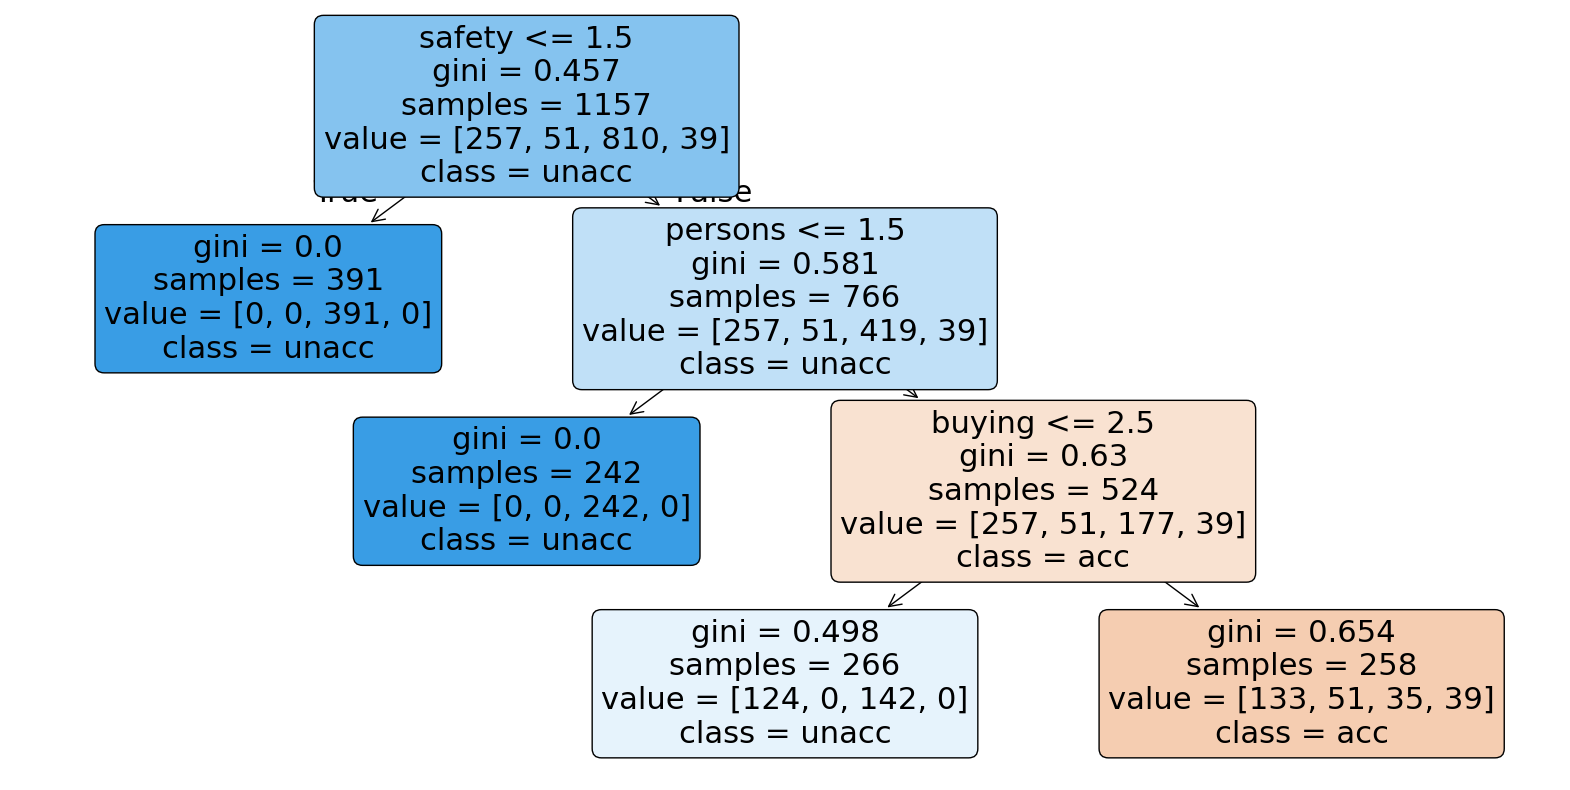

In [60]:
from sklearn.tree import DecisionTreeClassifier ,plot_tree
plt.figure(figsize=(20,10))
from sklearn import tree
tree.plot_tree(clf_gini,feature_names=x.columns,class_names=clf_gini.classes_,filled=True,rounded=True)

In [61]:
from sklearn.tree import DecisionTreeClassifier
clf_en=DecisionTreeClassifier(criterion='entropy' ,max_depth=3 ,random_state=0)

In [62]:
clf_en.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

In [63]:
y_pred_clf_en=clf_en.predict(x_test)

In [64]:
from sklearn.metrics import accuracy_score
print("Model accuracy {0:0.4f}".format(accuracy_score(y_test,y_pred_clf_en)))

Model accuracy 0.8053


In [65]:
from sklearn.metrics import  confusion_matrix
cm=confusion_matrix(y_test,y_pred_clf_en)
cm


array([[ 71,   0,  56,   0],
       [ 18,   0,   0,   0],
       [ 11,   0, 388,   0],
       [ 26,   0,   0,   0]])

In [66]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_clf_en))

              precision    recall  f1-score   support

         acc       0.56      0.56      0.56       127
        good       0.00      0.00      0.00        18
       unacc       0.87      0.97      0.92       399
       vgood       0.00      0.00      0.00        26

    accuracy                           0.81       570
   macro avg       0.36      0.38      0.37       570
weighted avg       0.74      0.81      0.77       570

